In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("updated_cleaned_dataset.csv")

In [3]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("tree", DecisionTreeClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)


,steps,"[('tfidf', ...), ('tree', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [7]:
y_pred = pipeline.predict(X_test)

In [8]:
results = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": y_pred
})

print(results.head(10))

                                                    text  actual  predicted
13980  nonfat milk water sugar modified corn starch v...       0          0
28246  water soybean oil egg yolks vinegar corn syrup...       1          1
13161  organic sprouted wheat filtered water organic ...       0          0
15622  whole oat flour potato starch sugar expeller p...       0          0
36486                         natural farm raised shrimp       0          0
1450   pizza shells enriched wheat flour wheat flour ...       1          1
35334  enriched flour wheat flour iron niacin thiamin...       0          0
24703  enriched flour wheat flour niacin reduced iron...       1          1
26737  corn syrup solids sugar coconut oil instant co...       1          1
34882  filtered water high fructose corn syrup apple ...       0          0


In [9]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9934301958307012

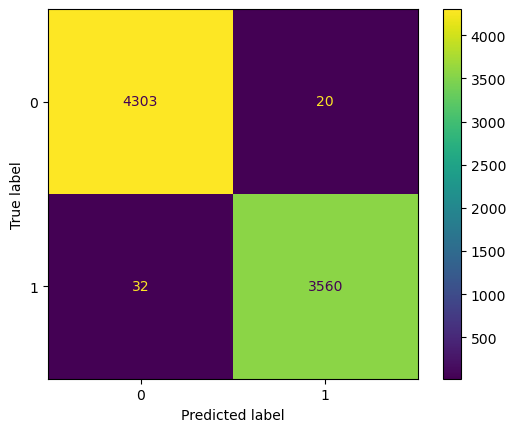

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [11]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4323
           1       0.99      0.99      0.99      3592

    accuracy                           0.99      7915
   macro avg       0.99      0.99      0.99      7915
weighted avg       0.99      0.99      0.99      7915



AUC: 0.9932324485955116


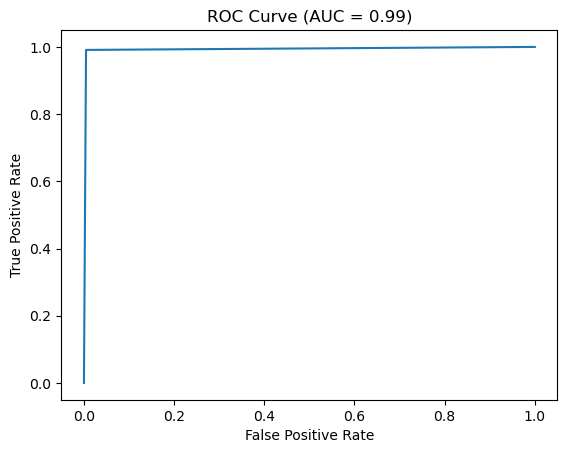

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc:.2f})")
plt.show()